In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the JSON results
json_path = "results/conv_inquiry_results.json"
with open(json_path, "r") as f:
    data = json.load(f)

print(f"Loaded results created at: {data['created']}")
print(f"Number of experiments: {len(data['results'])}")

# Group results by condition and kernel size for plotting
results_by_kernel = {}
for result in data['results']:
    k = result['kernel_size']
    if k not in results_by_kernel:
        results_by_kernel[k] = []
    results_by_kernel[k].append(result)

print(f"\nKernel sizes found: {sorted(results_by_kernel.keys())}")


Loaded results created at: 2026-02-24T20:13:02.912715Z
Number of experiments: 6

Kernel sizes found: [3, 5, 7]


✓ Saved train_accuracies.png


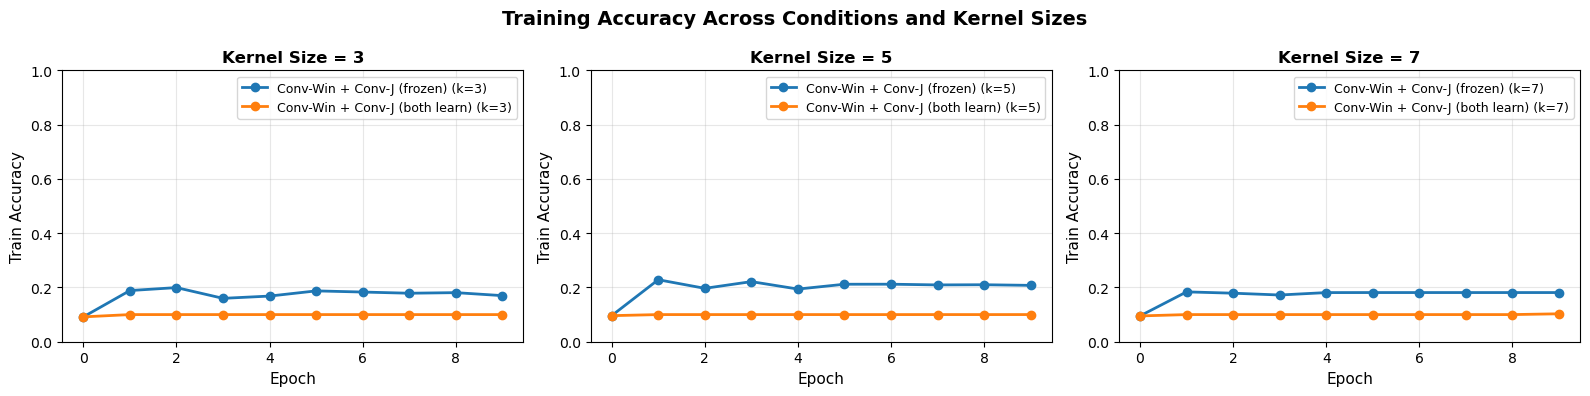

In [3]:
# Plot 1: Train Accuracies
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training Accuracy Across Conditions and Kernel Sizes", fontsize=14, fontweight="bold")

for idx, k in enumerate(sorted(results_by_kernel.keys())):
    ax = axes[idx]
    for result in results_by_kernel[k]:
        label = f"{result['condition']} (k={k})"
        ax.plot(result['train_accs'], marker='o', label=label, linewidth=2)
    
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Train Accuracy", fontsize=11)
    ax.set_title(f"Kernel Size = {k}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("results/train_accuracies.png", dpi=150, bbox_inches='tight')
print("✓ Saved train_accuracies.png")
plt.show()


✓ Saved test_accuracies.png


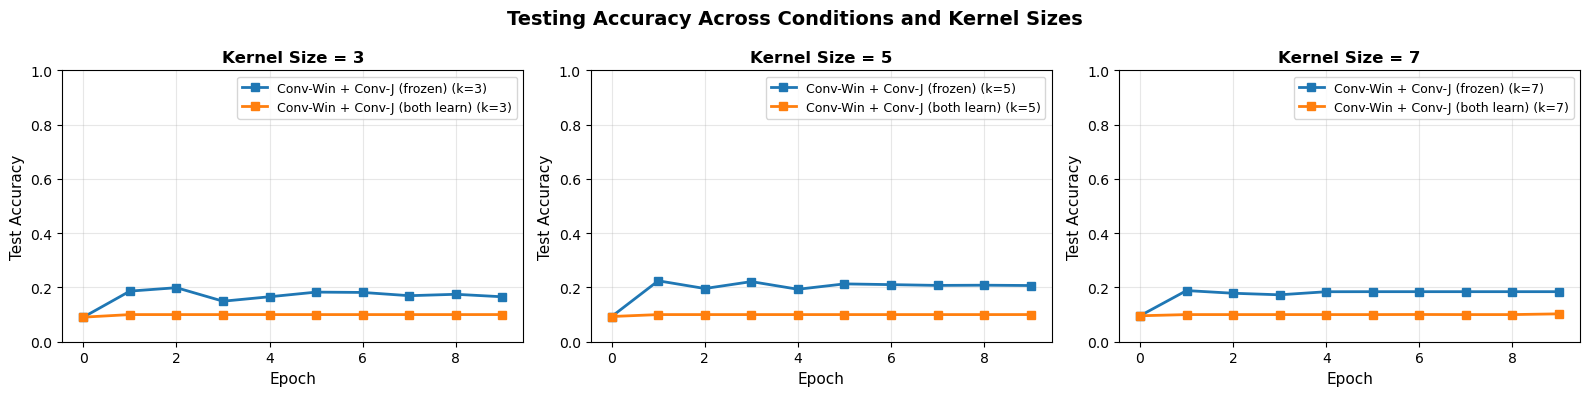

In [4]:
# Plot 2: Test Accuracies
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Testing Accuracy Across Conditions and Kernel Sizes", fontsize=14, fontweight="bold")

for idx, k in enumerate(sorted(results_by_kernel.keys())):
    ax = axes[idx]
    for result in results_by_kernel[k]:
        label = f"{result['condition']} (k={k})"
        ax.plot(result['test_accs'], marker='s', label=label, linewidth=2)
    
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Test Accuracy", fontsize=11)
    ax.set_title(f"Kernel Size = {k}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("results/test_accuracies.png", dpi=150, bbox_inches='tight')
print("✓ Saved test_accuracies.png")
plt.show()


In [5]:
# Summary Table: Final Accuracies
import pandas as pd

summary_data = []
for result in data['results']:
    final_train = result['train_accs'][-1]
    final_test = result['test_accs'][-1]
    summary_data.append({
        'Kernel': result['kernel_size'],
        'Condition': result['condition'],
        'LR_Win': result['lr_win'],
        'LR_J': result['lr_j'],
        'Final Train Acc': f"{final_train:.4f}",
        'Final Test Acc': f"{final_test:.4f}",
        'N Params': result['n_params'],
        'Time (sec)': f"{result['time_sec']:.1f}"
    })

df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY TABLE: Final Accuracies and Metadata")
print("="*100)
print(df.to_string(index=False))
print("="*100)



SUMMARY TABLE: Final Accuracies and Metadata
 Kernel                      Condition  LR_Win  LR_J Final Train Acc Final Test Acc  N Params Time (sec)
      3     Conv-Win + Conv-J (frozen)   0.000 0.000          0.1698         0.1656    180616      619.1
      3 Conv-Win + Conv-J (both learn)   0.159 0.058          0.1000         0.1001    180616      636.2
      5     Conv-Win + Conv-J (frozen)   0.000 0.000          0.2077         0.2071    181256     1010.6
      5 Conv-Win + Conv-J (both learn)   0.159 0.058          0.1001         0.1001    181256     1048.5
      7     Conv-Win + Conv-J (frozen)   0.000 0.000          0.1812         0.1844    182216     1488.3
      7 Conv-Win + Conv-J (both learn)   0.159 0.058          0.1029         0.1027    182216     1491.9
